# 1. Introdução

# Modelo Baseline - Credit Risk

## Projeto: Credit Risk - Home Credit Default Risk

Este notebook tem como objetivo construir um modelo baseline para previsão de inadimplência (default), utilizando o dataset previamente preparando na etapa de engenharia de variáveis.

O modelo baseline serve como ponto de partida para avaliação de desempenho, permitindo comparar futuras abordagens mais complexas.

# Bibliotecas Utilizadas

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 2. Carregamento dos Dados Processados

Os dados utilizados nesta etapa foram previamente tratados e armazenados na pasta `data/processed/`, garantindo separação entre dados brutos e dados prontos para modelagem.

In [4]:
# CARREGAMENTO DAS FEATURES E DO TARGET JÁ PROCESSADOS
features_processed = pd.read_parquet('../data/processed/Features_processed.parquet')
target_processed =  pd.read_parquet('../data/processed/Target_processed.parquet')

# 3. Verificação Inicial dos Dados

Nesta seção são realizadas verificações básicas no dataset, incluindo:
- Dimensão dos dados
- Tipos de variáveis
- Integridade dos dados

In [24]:
display(features_processed.head(10))
print('Caractéricas dos dados das Features')
print('Formato das features: {}'.format(features_processed.shape))
print(features_processed.dtypes.value_counts())
print('Int8 = Features Categorias\nFloat64 = Features Numéricas Continuas\nInt64 = Features Numéricas Discretas')

,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Unknown,WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Unknown,EMERGENCYSTATE_MODE_Yes,RATIO_CREDIT_INCOME,RATIO_ANNUITY_INCOME,CREDIT_PER_PERSON,INCOME_PER_PERSON,RATIO_CREDIT_GOODS
0,100002.0,0.0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461.0,-637.0,-3648.0,...,1,0,0,0,0,2.007889,0.121978,406597.50,202500.0,1.158397
1,100003.0,0.0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765.0,-1188.0,-1186.0,...,0,0,0,0,0,4.790750,0.132217,646751.25,135000.0,1.145199
2,100004.0,0.0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046.0,-225.0,-4260.0,...,0,1,0,1,0,2.000000,0.100000,135000.00,67500.0,1.000000
3,100006.0,0.0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005.0,-3039.0,-9833.0,...,0,1,0,1,0,2.316167,0.219900,156341.25,67500.0,1.052803
4,100007.0,0.0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932.0,-3038.0,-4311.0,...,0,1,0,1,0,4.222222,0.179963,513000.00,121500.0,1.000000
5,100008.0,0.0,99000.0,490495.5,27517.5,454500.0,0.035792,-16941.0,-1588.0,-4970.0,...,0,1,0,1,0,4.954500,0.277955,245247.75,49500.0,1.079198
6,100009.0,1.0,171000.0,1560726.0,41301.0,1395000.0,0.035792,-13778.0,-3130.0,-1213.0,...,0,1,0,1,0,9.127053,0.241526,520242.00,57000.0,1.118800
7,100010.0,0.0,360000.0,1530000.0,42075.0,1530000.0,0.003122,-18850.0,-449.0,-4597.0,...,0,1,0,1,0,4.250000,0.116875,765000.00,180000.0,1.000000
8,100011.0,0.0,112500.0,1019610.0,33826.5,913500.0,0.018634,-20099.0,365243.0,-7427.0,...,0,1,0,1,0,9.063200,0.300680,509805.00,56250.0,1.116158
9,100012.0,0.0,135000.0,405000.0,20250.0,405000.0,0.019689,-14469.0,-2019.0,-14437.0,...,0,1,0,1,0,3.000000,0.150000,405000.00,135000.0,1.000000


Caractéricas dos dados das Features
Formato das features: (307511, 311)
int8       130
float64    114
int64       67
Name: count, dtype: int64
Int8 = Features Categorias
Float64 = Features Numéricas Continuas
Int64 = Features Numéricas Discretas


In [45]:
display(target_processed.head(10))
print('Caractéricas dos dados do target')
print('Formato do target: {}'.format(target_processed.shape))
print(target_processed.dtypes.value_counts())

# REESTRUTURANDO O TARGET COM O RAVEL DE UM DATAFRAME PARA UM ARRAY
target_processed_corrigido = target_processed.values.ravel()
target_processed_corrigido

,TARGET
0,1
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


Caractéricas dos dados do target
Formato do target: (307511, 1)
int64    1
Name: count, dtype: int64


array([1, 0, 0, ..., 0, 1, 0], shape=(307511,))

# 4. Separação Treino e Teste

Os dados são divididos em conjuntos de treino e teste, permitiindo avaliar o desempenho do modelo em dados não vistos durante o treinamento.

In [50]:
# DIVIDINDO OS DADOS EM TREINO E TEST (30% PARA TESTE), random_state = 0 e shuffle (embaralhamento = Verdadeiro)
x_treino, x_teste, y_treino, y_teste = train_test_split(features_processed, target_processed_corrigido, shuffle = True, test_size = 0.3, random_state  = 0, stratify = target_processed_corrigido)

# 5.  Modelo Baseline - Regressão Logística

A regressão Logística foi selecionada como modelo baseline devido à sua interpretabilidade, simplicidade e ampla utilização em modelos de risco de crédito.

Além de serviv como referência de desempenho para futuras abordagens, o modelos permite compreemder a infliência das variáveis na probabilidade de inamdimplÇencia dos clientes.

In [51]:
# MODELO INICIAL
modelo = LogisticRegression(
    max_iter = 1500,
    random_state = 0
)
modelo.fit(x_treino, y_treino)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,1500
,multi_class,'deprecated'


# 6. Previsões do Modelo

Nesta etapa são realizadas as previsões do modelo sobre o conjunto de teste.

In [54]:
# PREVISÕES FEITA PELO MODELO
previsoes_modelo = modelo.predict(x_teste)
print('previsões do modelo: {}'.format(previsoes_modelo))


# PROBABILIDADE DE INADIMPLÊNCIA
print('probabilidade das previsões: {}'.format(probabilidade_modelo))
probabilidade_modelo = modelo.predict_proba(x_teste)[:, 1]

previsões do modelo: [0 0 0 ... 0 0 0]
probabilidade das previsões: [0.07996057 0.10403316 0.0603419  ... 0.03016542 0.11054014 0.04423715]


# 7. Avaliação do Modelo

O modelo será avaliado utilizando métricas adequadas para problemas de classificação desbalanceada, comuns em risco de crédito.

## 7.1. Classification Report

In [55]:
# ESTATISTICA DO MODELO
print(classification_report(y_teste, previsoes_modelo))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     84806
           1       0.00      0.00      0.00      7448

    accuracy                           0.92     92254
   macro avg       0.46      0.50      0.48     92254
weighted avg       0.85      0.92      0.88     92254



## 7.2. Matriz de Confusão

In [56]:
# MATRIZ DE CONFUSÃO
print(confusion_matrix(y_teste, previsoes_modelo))

[[84805     1]
 [ 7448     0]]


## 7.3. AUC-ROC

In [60]:
# PORCENTEGEM DO AUC ROC
print('AUC ROC {:.2f}%'.format(roc_auc_score(y_teste, probabilidade_modelo)))

AUC ROC 0.63%


## 7.4. Curva ROC

A Curva ROC foi utilizada para avaliar a capacidade da Regressão Logística em
distinguir clientes adimplentes e inadimplentes sob diferentes limiares
(thresholds) de classificação.

Observa-se que a curva se mantém acima da diagonal de referência, indicando que
o modelo apresenta desempenho superior ao acaso na tarefa de separação das classes.
Esse comportamento é corroborado pelo valor de AUC-ROC igual a aproximadamente
0,63.

Embora o resultado demonstre a existência de sinal preditivo nos dados, a capacidade
de discriminação ainda é limitada, sugerindo dificuldade do modelo em identificar
inadimplentes de forma consistente utilizando o threshold padrão de classificação.

Esse comportamento é esperado em função do forte desbalanceamento observado na
variável target, onde a classe adimplente representa a maior parte das observações.

Ainda assim, o resultado obtido pelo modelo baseline é relevante por demonstrar que
existe capacidade de ranqueamento de risco nos dados, servindo como referência para
comparação com modelos mais robustos e técnicas específicas para tratamento do
desbalanceamento nas próximas etapas do projeto.

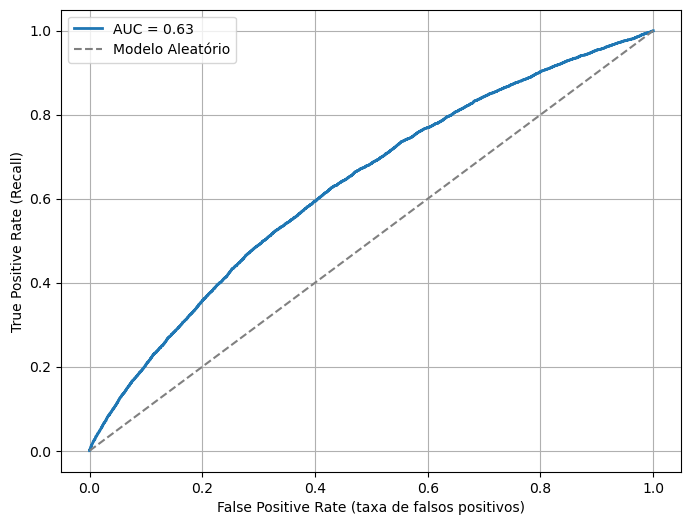

In [66]:
# CURVA ROC PARA ENTENDER A CAPACIDADE DE SEPARAÇÃO DAS CLASSES PELO MODELO
fpr, tpr, thresholds = roc_curve(y_teste, probabilidade_modelo)
auc = roc_auc_score(y_teste, probabilidade_modelo)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label = f'AUC = {auc:.2f}', linewidth = 2)

plt.plot([0,1],
        [0,1],
        linestyle = '--',
        color = 'gray',
        label = 'Modelo Aleatório')

plt.xlabel('False Positive Rate (taxa de falsos positivos)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.grid(True)

plt.show()

## 7.5. Curva Precision-Recall

Observa-se que a precisão do modelo cai rapidamente à medida que o recall
aumenta. Esse comportamento indica que, para capturar uma quantidade maior
de clientes inadimplentes, o modelo passa a classificar também um número
significativo de clientes adimplentes como inadimplentes.

A rápida redução da precisão sugere que a capacidade de separação entre as
classes ainda é limitada, comportamento esperado diante do forte
desbalanceamento presente na variável target.

Apesar disso, a curva demonstra que o modelo possui algum poder de
ranqueamento, resultado consistente com o AUC-ROC de aproximadamente 0,63
obtido anteriormente.

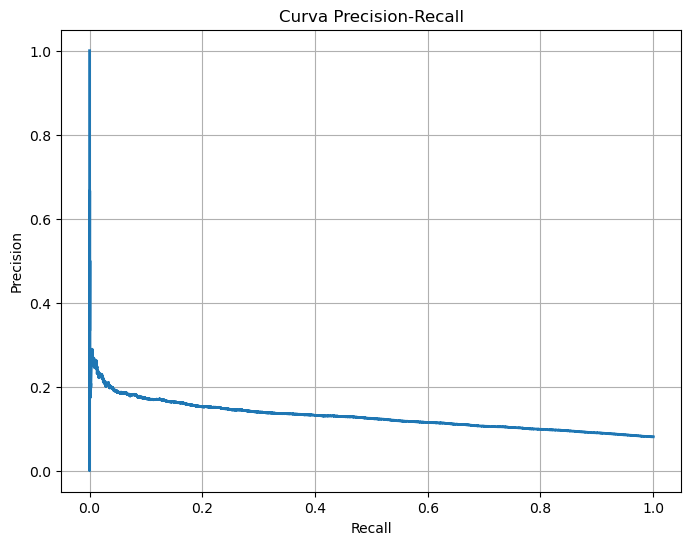

In [73]:
# CURVA PRECISION-RECALL PARA ENTENDER O COMPORTAMENTO DA PRECISÃO E DO RECALL BASEADO EM VARIOS THRESHOLDS DIFERENTES
precision, recall, thresholds = precision_recall_curve(
    y_teste,
    probabilidade_modelo
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.grid(True)

plt.show()

# 9. Interpretação dos Resultados

O modelo baseline apresentou elevada acurácia (92%), porém esse resultado deve ser interpretado com cautela devido ao forte desbalanceamento da variável target identificado durante a etapa de EDA.

Observa-se que o modelo classificou praticamente todas as observações como adimplentes, não sendo capaz de identificar clientes inadimplentes no conjunto de teste. Esse comportamento é evidenciado pelo recall de 0% para a classe inadimplente.

Apesar disso, a métrica AUC-ROC atingiu aproximadamente 0,63, indicando que o modelo possui alguma capacidade de separação entre clientes adimplentes e inadimplentes quando analisadas as probabilidades previstas.

A Curva Precision-Recall demonstra que, à medida que se reduz o threshold de classificação para aumentar a identificação de clientes inadimplentes (Recall), ocorre uma rápida queda na precisão do modelo. Esse comportamento indica que, para capturar uma quantidade maior de inadimplentes, o modelo passa a classificar também um número significativo de clientes adimplentes como inadimplentes.

Os resultados sugerem que o principal desafio atual está relacionado ao desbalanceamento das classes e à definição do limiar de classificação, fatores que serão explorados nas próximas etapas por meio de técnicas específicas para classificação desbalanceada.

# 10. Conclusões do Modelo Baseline

O modelo baseline construído por meio da Regressão Logística apresentou
desempenho superior ao acaso, alcançando AUC-ROC de aproximadamente 0,63.

Apesar da elevada acurácia observada, a análise detalhada das métricas mostrou
que o modelo possui dificuldades para identificar clientes inadimplentes,
classificando predominantemente a classe adimplente.

Esse comportamento está diretamente relacionado ao forte desbalanceamento da
variável target, evidenciando a necessidade de técnicas adicionais para melhorar
a identificação da classe positiva.

Ainda assim, o modelo demonstrou capacidade inicial de separação entre clientes
adimplentes e inadimplentes, estabelecendo um ponto de referência para comparação
com futuras abordagens.


# 11. Próximos Passos


 Ajuste de hiperparâmetros
- Teste de modelos mais complexos (Random Forest, XGBoost)
- Análise de importância das variáveis
- Aplicação de técnicas para lidar com desbalanceamento
- Avaliação de métricas adicionais (KS, Precision-Recall)
